# Arabic Handwritten Word Recognition — v2 (GPU + 64×64 + CLAHE)
**Run cells top to bottom. Do not skip any cell.**

### Key improvements over previous version
- Automatically uses CUDA GPU when available (much faster training)
- CNN input size raised from 32×32 → **64×64** (preserves dot position, stroke endings)
- Deeper CNN with more filters and Spatial Dropout
- Training augmentation includes: Gaussian noise, dilation (simulates thick brush), brightness/contrast shifts
- Inference preprocessing uses **CLAHE** to normalize ink darkness across image styles
- Conservative wide-box splitting (fewer false splits on cursive text)
- Smarter multi-hypothesis: low-confidence predictions are flagged explicitly
- All my_chars folders preserved


## Cell 1 — Install

In [8]:
# Install required packages.
# This notebook is intended to run inside WSL2 (Ubuntu) for true NVIDIA CUDA acceleration.
# Run this cell from the Linux kernel/environment (not native Windows Python).
!pip install --upgrade pip
!pip install "tensorflow[and-cuda]" ultralytics opencv-python-headless matplotlib scikit-learn tqdm

# Optional sanity checks (safe to keep):
import tensorflow as tf
print("TF version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

TF version: 2.21.0
GPUs: []


## Cell 2 — Imports & Paths

In [13]:
import numpy as np
import cv2
import os
import re
import random
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization,
    SpatialDropout2D, GlobalAveragePooling2D, Input
)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import regularizers
from ultralytics import YOLO

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# ─── GPU detection ────────────────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU(s) found: {[g.name for g in gpus]}")
    for g in gpus:
        tf.config.experimental.set_memory_growth(g, True)
    DEVICE = '0'  # YOLO GPU index
else:
    print("No GPU found — using CPU (training will be slow)")
    DEVICE = 'cpu'

# ─── Paths ────────────────────────────────────────────────────────────────────
ROOT        = Path(r"F:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN")
AHAWP_DIR   = ROOT / "isolated_alphabets_per_alphabet"
MY_CHARS    = ROOT / "my_chars"
MY_DATASET  = ROOT / "my_dataset"
MNIST_TRAIN = ROOT / "arabic-chars-mnist" / "train"
MNIST_TEST  = ROOT / "arabic-chars-mnist" / "test"

# ─── Image size (raised from 32 to 64) ───────────────────────────────────────
IMG_SIZE = 64

# ─── Arabic letter name registry ─────────────────────────────────────────────
ARABIC_28 = [
    'ain','alef','beh','dad','dal','feh','ghain','hah','heh','jeem',
    'kaf','khah','lam','meem','noon','qaf','reh','sad','seen','sheen',
    'tah','teh','thal','theh','waw','yeh','zah','zain'
]

AHAWP_TO_STD = {
    'ain':'ain','alif':'alef','beh':'beh','dal':'dal','feh':'feh',
    'heh':'heh','jeem':'jeem','kaf':'kaf','lam':'lam','meem':'meem',
    'noon':'noon','qaf':'qaf','raa':'reh','sad':'sad','seen':'seen',
    'tah':'tah','waw':'waw','yaa':'yeh',
    'dad':'dad','ghain':'ghain','hah':'hah','khah':'khah',
    'sheen':'sheen','teh':'teh','thal':'thal','theh':'theh',
    'zah':'zah','zain':'zain',
}

# All my_chars subfolders are preserved here (none skipped intentionally)
MYCHARS_TO_STD = {
    'ain_beginning':'ain','ain_end':'ain','ain_middle':'ain','ain_isolated':'ain',
    'alif_end':'alef','alif_isolated':'alef','alif_hamza':'alef',
    'beh_beginning':'beh','beh_end':'beh','beh_middle':'beh','beh_isolated':'beh',
    'dad_beginning':'dad','dad_end':'dad','dad_middle':'dad','dad_isolated':'dad',
    'dal_end':'dal','dal_isolated':'dal',
    'feh_beginning':'feh','feh_end':'feh','feh_middle':'feh','feh_isolated':'feh',
    'ghain_beginning':'ghain','ghain_end':'ghain','ghain_middle':'ghain','ghain_isolated':'ghain',
    'hah_beginning':'hah','hah_end':'hah','hah_middle':'hah','hah_isolated':'hah',
    'heh_beginning':'heh','heh_end':'heh','heh_middle':'heh','heh_isolated':'heh',
    'jeem_beginning':'jeem','jeem_end':'jeem','jeem_middle':'jeem','jeem_isolated':'jeem',
    'kaf_beginning':'kaf','kaf_end':'kaf','kaf_middle':'kaf','kaf_isolated':'kaf',
    'khah_beginning':'khah','khah_end':'khah','khah_middle':'khah','khah_isolated':'khah',
    'lam_beginning':'lam','lam_end':'lam','lam_middle':'lam','lam_isolated':'lam','lam_alif':'lam',
    'meem_beginning':'meem','meem_end':'meem','meem_middle':'meem','meem_isolated':'meem',
    'noon_beginning':'noon','noon_end':'noon','noon_middle':'noon','noon_isolated':'noon',
    'qaf_beginning':'qaf','qaf_end':'qaf','qaf_middle':'qaf','qaf_isolated':'qaf',
    'raa_end':'reh','raa_isolated':'reh',
    'sad_beginning':'sad','sad_end':'sad','sad_middle':'sad','sad_isolated':'sad',
    'seen_beginning':'seen','seen_end':'seen','seen_middle':'seen','seen_isolated':'seen',
    'sheen_beginning':'sheen','sheen_end':'sheen','sheen_middle':'sheen','sheen_isolated':'sheen',
    'tah_end':'tah','tah_middle':'tah','tah_isolated':'tah',
    'teh_beginning':'teh','teh_end':'teh','teh_middle':'teh','teh_isolated':'teh',
    'thal_end':'thal','thal_isolated':'thal',
    'theh_beginning':'theh','theh_end':'theh','theh_middle':'theh','theh_isolated':'theh',
    'waw_end':'waw','waw_isolated':'waw',
    'yaa_beginning':'yeh','yaa_end':'yeh','yaa_middle':'yeh','yaa_isolated':'yeh',
    'zah_beginning':'zah','zah_end':'zah','zah_isolated':'zah',
    'zain_end':'zain','zain_isolated':'zain',
}

MISSING_10 = {'dad','ghain','hah','khah','sheen','teh','thal','theh','zah','zain'}

print(f"TensorFlow : {tf.__version__}")
for p in [ROOT, AHAWP_DIR, MY_DATASET]:
    print(f"  {'OK    ' if p.exists() else 'MISSING'}: {p}")

No GPU found — using CPU (training will be slow)
TensorFlow : 2.21.0
  OK    : F:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN
  OK    : F:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN\isolated_alphabets_per_alphabet
  OK    : F:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN\my_dataset


## Cell 3 — Augmentation helpers (simulate real handwriting styles)

In [3]:
def augment_image(img_gray):
    """
    Apply random augmentations to a grayscale image to bridge the gap
    between clean isolated-letter datasets and thick-brush cursive inference.
    img_gray: uint8 numpy array (values 0-255, white background)
    Returns: augmented uint8 grayscale image, same size.
    """
    aug = img_gray.copy()

    # 1) Gaussian noise (simulate paper texture)
    if random.random() < 0.4:
        noise = np.random.normal(0, 8, aug.shape).astype('int32')
        aug = np.clip(aug.astype('int32') + noise, 0, 255).astype('uint8')

    # 2) Random brightness/contrast shift (simulate ink darkness variation)
    if random.random() < 0.5:
        alpha = random.uniform(0.7, 1.3)   # contrast
        beta  = random.randint(-30, 30)    # brightness
        aug = np.clip(alpha * aug.astype('float32') + beta, 0, 255).astype('uint8')

    # 3) Morphological dilation (simulate thick brush strokes)
    if random.random() < 0.35:
        k = random.choice([2, 3])
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
        # Ink is dark on white — invert, dilate, invert back
        inv = cv2.bitwise_not(aug)
        inv = cv2.dilate(inv, kernel, iterations=1)
        aug = cv2.bitwise_not(inv)

    # 4) Slight Gaussian blur (simulate motion or out-of-focus)
    if random.random() < 0.25:
        aug = cv2.GaussianBlur(aug, (3, 3), 0)

    return aug


print("Augmentation helpers ready.")

Augmentation helpers ready.


## Cell 4 — Load All Data Sources

In [4]:
def load_grayscale_folder(folder, label_map, img_size=IMG_SIZE):
    """Load PNGs from subfolders. label_map maps subfolder name -> standard label."""
    images, labels = [], []
    skipped = {}
    alias = {'alif': 'alef', 'raa': 'reh', 'yaa': 'yeh', 'zal': 'thal'}

    for subfolder in sorted(Path(folder).iterdir()):
        if not subfolder.is_dir():
            continue

        std = label_map.get(subfolder.name)
        if std is None and subfolder.name in ARABIC_28:
            std = subfolder.name
        if std is None and subfolder.name in alias:
            std = alias[subfolder.name]
        if std is None:
            parts = subfolder.name.rsplit('_', 1)
            if len(parts) == 2:
                std = label_map.get(parts[0])
                if std is None and parts[0] in ARABIC_28:
                    std = parts[0]
                if std is None and parts[0] in alias:
                    std = alias[parts[0]]

        if std is None:
            skipped[subfolder.name] = skipped.get(subfolder.name, 0) + 1
            continue

        for img_path in subfolder.glob('*.png'):
            img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, (img_size, img_size))
            img_bgr = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
            images.append(img_bgr)
            labels.append(std)

    X = np.array(images, dtype='float32') / 255.0
    print(f"  {Path(folder).name}: {len(X)} images, {len(set(labels))} classes, shape {X.shape}")
    if skipped:
        print(f"  {Path(folder).name} skipped folders (not in label map): {sorted(skipped.keys())}")
    return X, np.array(labels)


def load_mnist_missing(train_path, test_path, missing_set=MISSING_10, img_size=IMG_SIZE):
    """Load Arabic MNIST images for the 10 letters missing from AHAWP."""
    images, labels = [], []
    for path in [train_path, test_path]:
        if not Path(path).exists():
            continue
        for filename in os.listdir(path):
            label = re.sub(r'[0-9]+|\.jpg$|\.png$', '', filename)
            if label not in missing_set:
                continue
            img = cv2.imread(os.path.join(path, filename))
            if img is None:
                continue
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            gray = cv2.resize(gray, (img_size, img_size))
            img_bgr = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
            images.append(img_bgr)
            labels.append(label)
    if not images:
        print("  Arabic MNIST missing: 0 images found")
        return np.array([]).reshape(0, img_size, img_size, 3), np.array([])
    X = np.array(images, dtype='float32') / 255.0
    print(f"  Arabic MNIST (missing 10): {len(X)} images, {len(set(labels))} classes, shape {X.shape}")
    return X, np.array(labels)


print("Loading datasets...")
X_ahawp, y_ahawp = load_grayscale_folder(AHAWP_DIR, AHAWP_TO_STD)
X_mine,  y_mine  = load_grayscale_folder(MY_CHARS,  MYCHARS_TO_STD) if MY_CHARS.exists() else (np.array([]).reshape(0,IMG_SIZE,IMG_SIZE,3), np.array([]))
X_mnist, y_mnist = load_mnist_missing(MNIST_TRAIN, MNIST_TEST)

parts_X = [x for x in [X_ahawp, X_mine, X_mnist] if len(x) > 0]
parts_y = [y for y in [y_ahawp, y_mine, y_mnist] if len(y) > 0]
X_all   = np.concatenate(parts_X, axis=0)
y_all   = np.concatenate(parts_y, axis=0)

print(f"\nTotal combined : {len(X_all)} images, shape {X_all.shape}")
print(f"Classes found  : {sorted(set(y_all))}")
print(f"Missing from 28: {sorted(set(ARABIC_28) - set(y_all))}")

Loading datasets...
  isolated_alphabets_per_alphabet: 53350 images, 27 classes, shape (53350, 64, 64, 3)
  my_chars: 217 images, 28 classes, shape (217, 64, 64, 3)
  my_chars skipped folders (not in label map): ['hamza']
  Arabic MNIST (missing 10): 6000 images, 10 classes, shape (6000, 64, 64, 3)

Total combined : 59567 images, shape (59567, 64, 64, 3)
Classes found  : [np.str_('ain'), np.str_('alef'), np.str_('beh'), np.str_('dad'), np.str_('dal'), np.str_('feh'), np.str_('ghain'), np.str_('hah'), np.str_('heh'), np.str_('jeem'), np.str_('kaf'), np.str_('khah'), np.str_('lam'), np.str_('meem'), np.str_('noon'), np.str_('qaf'), np.str_('reh'), np.str_('sad'), np.str_('seen'), np.str_('sheen'), np.str_('tah'), np.str_('teh'), np.str_('thal'), np.str_('theh'), np.str_('waw'), np.str_('yeh'), np.str_('zah'), np.str_('zain')]
Missing from 28: []


## Cell 5 — Encode Labels & Split

In [5]:
le = LabelEncoder()
y_encoded   = le.fit_transform(y_all)
NUM_CLASSES = len(le.classes_)

np.save('label_classes_v2.npy', le.classes_)

print(f"Total classes : {NUM_CLASSES}")
print(f"Class names   : {list(le.classes_)}")

counts = Counter(y_encoded)
rare   = [le.classes_[k] for k, v in counts.items() if v < 2]
if rare:
    print(f"\nWARNING: Classes with <2 samples (dropped from split): {rare}")
    mask      = np.array([counts[y] >= 2 for y in y_encoded])
    X_all     = X_all[mask]
    y_encoded = y_encoded[mask]

# 80% train / 10% val / 10% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_encoded, test_size=0.20, random_state=SEED, stratify=y_encoded
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f"\nTrain: {X_train.shape}")
print(f"Val  : {X_val.shape}")
print(f"Test : {X_test.shape}")

Total classes : 28
Class names   : [np.str_('ain'), np.str_('alef'), np.str_('beh'), np.str_('dad'), np.str_('dal'), np.str_('feh'), np.str_('ghain'), np.str_('hah'), np.str_('heh'), np.str_('jeem'), np.str_('kaf'), np.str_('khah'), np.str_('lam'), np.str_('meem'), np.str_('noon'), np.str_('qaf'), np.str_('reh'), np.str_('sad'), np.str_('seen'), np.str_('sheen'), np.str_('tah'), np.str_('teh'), np.str_('thal'), np.str_('theh'), np.str_('waw'), np.str_('yeh'), np.str_('zah'), np.str_('zain')]

Train: (47653, 64, 64, 3)
Val  : (5957, 64, 64, 3)
Test : (5957, 64, 64, 3)


## Cell 6 — Train CNN  (deeper, 64×64, augmentation, class weights)

In [ ]:
# ─── Class weights to handle imbalance (my_chars has fewer images per class) ──
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights_arr))

# ─── Training runtime guard (optional GPU, falls back to CPU) ────────────────
REQUIRE_GPU = False  # Set to False to allow CPU training

# ─── Data augmentation pipeline ───────────────────────────────────────────────
# Pixel-level augmentations (noise, dilation, contrast shifts) are done per-sample.
BATCH_SIZE = 64

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_4             │ (None, 32, 32, 32)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_5             │ (None, 16, 16, 64)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_6             │ (None, 8, 8, 128)      │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 2,823,228 (10.77 MB)

 Trainable params: 2,820,796 (10.76 MB)

 Non-trainable params: 2,432 (9.50 KB)

Training CNN on 47653 images, 28 classes, input 64×64...
Epoch 1/80
744/744 ━━━━━━━━━━━━━━━━━━━━ 0s 559ms/step - accuracy: 0.2226 - loss: 3.0189
Epoch 1: val_accuracy improved from None to 0.64147, saving model to arabic_cnn_v2.keras

Epoch 1: finished saving model to arabic_cnn_v2.keras
744/744 ━━━━━━━━━━━━━━━━━━━━ 463s 579ms/step - accuracy: 0.3712 - loss: 2.2664 - val_accuracy: 0.6415 - val_loss: 1.2279 - learning_rate: 0.0010
Epoch 2/80
744/744 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - accuracy: 0.6811 - loss: 1.1256
Epoch 2: val_accuracy improved from 0.64147 to 0.83989, saving model to arabic_cnn_v2.keras

Epoch 2: finished saving model to arabic_cnn_v2.keras
744/744 ━━━━━━━━━━━━━━━━━━━━ 371s 499ms/step - accuracy: 0.7248 - loss: 0.9968 - val_accuracy: 0.8399 - val_loss: 0.6692 - learning_rate: 0.0010
Epoch 3/80
744/744 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.8180 - loss: 0.7399
Epoch 3: val_accuracy improved from 0.83989 to 0.89247, saving model to arabic_cnn_v2.keras

Epoch

## Cell 7 — Plot training curves

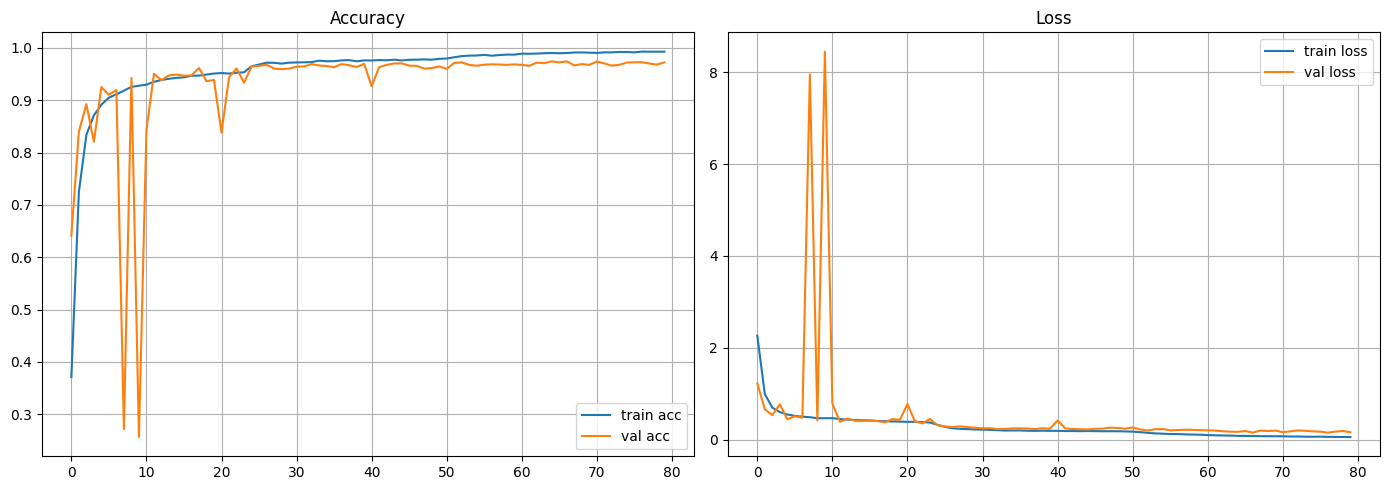

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history.history['accuracy'],     label='train acc')
ax1.plot(history.history['val_accuracy'], label='val acc')
ax1.set_title('Accuracy'); ax1.legend(); ax1.grid(True)
ax2.plot(history.history['loss'],         label='train loss')
ax2.plot(history.history['val_loss'],     label='val loss')
ax2.set_title('Loss'); ax2.legend(); ax2.grid(True)
plt.tight_layout()
plt.show()

## Cell 8 — YOLO: Prepare labels (single class = 'character')

In [10]:
def convert_to_single_class(dataset_dir):
    """Rewrite all YOLO label files so class index = 0 (we only detect 'character')."""
    for split in ['train', 'val']:
        labels_dir = Path(dataset_dir) / split / 'labels'
        if not labels_dir.exists():
            print(f"  Skipping {split} — labels folder not found")
            continue
        count = 0
        for txt in labels_dir.glob('*.txt'):
            lines = txt.read_text().splitlines()
            new_lines = []
            for line in lines:
                parts = line.strip().split()
                if len(parts) >= 5:
                    parts[0] = '0'
                    new_lines.append(' '.join(parts))
            txt.write_text('\n'.join(new_lines) + '\n')
            count += 1
        print(f"  {split}: converted {count} label files")

print("Converting YOLO labels to single class...")
convert_to_single_class(MY_DATASET)

train_imgs = list((MY_DATASET / 'train' / 'images').glob('*.*'))
val_imgs   = list((MY_DATASET / 'val'   / 'images').glob('*.*'))
print(f"Train images: {len(train_imgs)}   Val images: {len(val_imgs)}")

Converting YOLO labels to single class...
  train: converted 60 label files
  val: converted 13 label files
Train images: 60   Val images: 13


## Cell 9 — YOLO: Write data.yaml

In [11]:
yaml_path = MY_DATASET / 'data.yaml'
with open(yaml_path, 'w') as f:
    f.write(f"path: {MY_DATASET.as_posix()}\n")
    f.write("train: train/images\n")
    f.write("val: val/images\n")
    f.write("nc: 1\n")
    f.write("names:\n  - character\n")
print(open(yaml_path).read())

path: F:/newbach/Arabic-Handwritten-Characters-Recognition-using-CNN/my_dataset
train: train/images
val: val/images
nc: 1
names:
  - character



## Cell 10 — YOLO: Train  (GPU if available)

In [ ]:
# ─── YOLO training (GPU if available, CPU if not) ─────────────────────────
print(f"YOLO will train on device: {DEVICE}")

yolo_model = YOLO('yolov8s.pt')

## Cell 11 — Load Models for Inference

In [ ]:
CNN_MODEL_PATH  = ROOT / 'arabic_cnn_v2.keras'
LABEL_PATH      = ROOT / 'label_classes_v2.npy'
YOLO_WEIGHTS    = ROOT / 'my_yolo_v2' / 'char_detector' / 'weights' / 'best.pt'

for name, p in [('CNN model', CNN_MODEL_PATH), ('Labels', LABEL_PATH), ('YOLO weights', YOLO_WEIGHTS)]:
    if not p.exists():
        raise FileNotFoundError(f"Missing {name}: {p}")

cnn_model     = load_model(str(CNN_MODEL_PATH))
yolo_detector = YOLO(str(YOLO_WEIGHTS))
label_classes = np.load(str(LABEL_PATH), allow_pickle=True)

# Sanity checks
if cnn_model.output_shape[-1] != len(label_classes):
    raise ValueError(
        f"Mismatch: model outputs {cnn_model.output_shape[-1]} but labels has {len(label_classes)}"
    )
if cnn_model.input_shape[1:] != (IMG_SIZE, IMG_SIZE, 3):
    raise ValueError(
        f"Model input shape {cnn_model.input_shape[1:]} != expected ({IMG_SIZE},{IMG_SIZE},3)"
    )

print(f"CNN input  : {cnn_model.input_shape}")
print(f"CNN output : {cnn_model.output_shape}")
print(f"Labels     : {list(label_classes)}")
print(f"YOLO       : {YOLO_WEIGHTS}")
print("Models loaded successfully.")

## Cell 12 — Preprocessing & Inference Functions

In [ ]:
# ─── CONFIDENCE threshold for flagging uncertain predictions ──────────────────
LOW_CONF_THRESHOLD = 0.40  # predictions below this are reported as uncertain


def preprocess_crop(crop_bgr, img_size=IMG_SIZE):
    """
    Prepare a YOLO crop for CNN classification.
    Key improvements:
    - CLAHE (Contrast Limited Adaptive Histogram Equalization) to normalize
      ink darkness across different writing styles (thin pen vs thick brush).
    - Tight crop around actual ink pixels (removes surrounding whitespace).
    - Centered on a white canvas with 15% padding before resize.
    """
    gray = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY)

    # CLAHE: equalise contrast locally — normalises thick-brush vs thin-pen styles
    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(4, 4))
    gray  = clahe.apply(gray)

    # Light denoising
    gray = cv2.GaussianBlur(gray, (3, 3), 0)

    # Threshold to find ink pixels (dark on white)
    _, binary = cv2.threshold(
        gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )
    coords = cv2.findNonZero(binary)
    if coords is None:
        return None, None

    x, y, w, h = cv2.boundingRect(coords)
    roi_gray = gray[y:y+h, x:x+w]
    if roi_gray.size == 0:
        return None, None

    # Place tight crop on a white square canvas with 15% padding
    pad  = int(max(h, w) * 0.15)
    side = max(4, h + 2*pad, w + 2*pad)
    canvas = np.full((side, side), 255, dtype='uint8')
    ox, oy = (side - w) // 2, (side - h) // 2
    canvas[oy:oy+h, ox:ox+w] = roi_gray

    resized   = cv2.resize(canvas, (img_size, img_size), interpolation=cv2.INTER_LANCZOS4)
    final_bgr = cv2.cvtColor(resized, cv2.COLOR_GRAY2BGR)
    model_inp = np.expand_dims(final_bgr.astype('float32') / 255.0, axis=0)

    debug = {'gray': gray, 'binary': binary, 'resized': resized}
    return model_inp, debug


def box_iou_xyxy(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    iw, ih   = max(0, ix2-ix1), max(0, iy2-iy1)
    inter    = iw * ih
    if inter <= 0:
        return 0.0
    area_a = max(1, (ax2-ax1)*(ay2-ay1))
    area_b = max(1, (bx2-bx1)*(by2-by1))
    return float(inter / (area_a + area_b - inter))


def intersection_over_small(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    iw, ih   = max(0, ix2-ix1), max(0, iy2-iy1)
    inter    = iw * ih
    if inter <= 0:
        return 0.0
    area_a = max(1, (ax2-ax1)*(ay2-ay1))
    area_b = max(1, (bx2-bx1)*(by2-by1))
    return float(inter / min(area_a, area_b))


def maybe_split_wide_box(img_bgr, box, median_w):
    """
    Split a box that is significantly wider than the median character width.
    Threshold raised to 1.7× (was 1.45×) to reduce false splits on cursive text
    where strokes naturally run wide.
    The valley must be < 60% of mean signal to be considered a real gap.
    """
    x1, y1, x2, y2, score = box
    w, h = x2 - x1, y2 - y1
    if w < 1.7 * max(1.0, median_w):
        return [box]

    crop = img_bgr[y1:y2, x1:x2]
    if crop.size == 0:
        return [box]

    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    _, bin_inv = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    proj = bin_inv.sum(axis=0).astype('float32')

    if len(proj) < 12:
        return [box]

    kernel = np.ones(9, dtype='float32') / 9.0
    smooth = np.convolve(proj, kernel, mode='same')

    s = int(0.30 * w)
    e = int(0.70 * w)
    if e <= s + 3:
        return [box]

    cut_local   = int(np.argmin(smooth[s:e])) + s
    valley      = float(smooth[cut_local])
    mean_signal = float(np.mean(smooth[s:e]))

    # More conservative split criterion (was 0.72, now 0.60)
    if valley > 0.60 * mean_signal:
        return [box]

    left_w  = cut_local
    right_w = w - cut_local
    if left_w < int(0.25 * w) or right_w < int(0.25 * w):
        return [box]

    b1 = (x1,           y1, x1 + cut_local, y2, score)
    b2 = (x1 + cut_local, y1, x2,           y2, score)
    return [b1, b2]


def suppress_bad_boxes(raw_boxes, img_h, img_w, iou_thr=0.45):
    if not raw_boxes:
        return []

    areas = np.array([(x2-x1)*(y2-y1) for x1,y1,x2,y2,_ in raw_boxes], dtype='float32')
    ws    = np.array([x2-x1             for x1,y1,x2,y2,_ in raw_boxes], dtype='float32')
    hs    = np.array([y2-y1             for x1,y1,x2,y2,_ in raw_boxes], dtype='float32')

    med_area = max(1.0, float(np.median(areas)))
    med_w    = max(1.0, float(np.median(ws)))
    med_h    = max(1.0, float(np.median(hs)))
    img_area = float(img_h * img_w)

    candidates = []
    for x1, y1, x2, y2, score in raw_boxes:
        w, h  = x2-x1, y2-y1
        area  = w * h
        aspect = w / max(1.0, h)
        if area   > min(0.35 * img_area, 2.8 * med_area): continue
        if aspect > 3.5 or aspect < 0.15:                 continue
        if w > 2.6 * med_w or h > 2.6 * med_h:           continue
        candidates.append((x1, y1, x2, y2, float(score)))

    if not candidates:
        candidates = [(x1, y1, x2, y2, float(score)) for x1,y1,x2,y2,score in raw_boxes]

    # Remove enclosing boxes that strongly contain a smaller box
    drop_idx = set()
    for i in range(len(candidates)):
        bi = candidates[i][:4]
        ai = max(1, (bi[2]-bi[0])*(bi[3]-bi[1]))
        for j in range(len(candidates)):
            if i == j: continue
            bj = candidates[j][:4]
            aj = max(1, (bj[2]-bj[0])*(bj[3]-bj[1]))
            if ai <= aj: continue
            if intersection_over_small(bi, bj) > 0.85 and ai > 1.6 * aj:
                drop_idx.add(i)
                break
    candidates = [b for k, b in enumerate(candidates) if k not in drop_idx]

    if not candidates:
        candidates = [(x1, y1, x2, y2, float(score)) for x1,y1,x2,y2,score in raw_boxes]

    # NMS
    candidates.sort(key=lambda t: t[4], reverse=True)
    keep = []
    for cand in candidates:
        if all(box_iou_xyxy(cand[:4], k[:4]) < iou_thr for k in keep):
            keep.append(cand)
    return keep


def order_detections_arabic(detections):
    """Order detections right-to-left within each text line."""
    if len(detections) <= 1:
        return detections

    enriched = []
    for d in detections:
        x1, y1, x2, y2 = d['box']
        h  = max(1, y2 - y1)
        cy = (y1 + y2) / 2.0
        dd = d.copy()
        dd['_h']  = h
        dd['_cy'] = cy
        enriched.append(dd)

    median_h = float(np.median([d['_h'] for d in enriched]))
    line_tol = max(8.0, 0.6 * median_h)

    lines = []
    for d in sorted(enriched, key=lambda z: z['_cy']):
        best_idx, best_dist = -1, np.inf
        for i, ln in enumerate(lines):
            dist = abs(d['_cy'] - ln['cy_mean'])
            if dist <= line_tol and dist < best_dist:
                best_idx, best_dist = i, dist
        if best_idx == -1:
            lines.append({'cy_mean': d['_cy'], 'items': [d]})
        else:
            lines[best_idx]['items'].append(d)
            lines[best_idx]['cy_mean'] = float(np.mean([it['_cy'] for it in lines[best_idx]['items']]))

    ordered = []
    for ln in sorted(lines, key=lambda ln: ln['cy_mean']):
        for d in sorted(ln['items'], key=lambda z: -z['box'][0]):
            d.pop('_h', None); d.pop('_cy', None)
            ordered.append(d)
    return ordered


def recognize_word(image_path, conf_threshold=0.25, iou_threshold=0.4, topk=5, return_debug=False):
    """
    Full pipeline: YOLO detection → crop → CLAHE preprocessing → CNN classification.
    Returns a list of character names in Arabic reading order (right → left).
    """
    img = cv2.imread(str(image_path))
    if img is None:
        raise FileNotFoundError(f"Cannot read: {image_path}")

    H, W      = img.shape[:2]
    annotated = img.copy()

    results = yolo_detector(img, conf=conf_threshold, iou=iou_threshold, verbose=False)[0]

    if len(results.boxes) == 0:
        print("No characters detected by YOLO.")
        if return_debug:
            return [], annotated, []
        return [], annotated

    raw_boxes = []
    confs = results.boxes.conf.cpu().numpy().tolist() if results.boxes.conf is not None else [1.0]*len(results.boxes)
    for box, score in zip(results.boxes, confs):
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(W, x2), min(H, y2)
        if x2 - x1 < 4 or y2 - y1 < 4:
            continue
        raw_boxes.append((x1, y1, x2, y2, float(score)))

    filt_boxes = suppress_bad_boxes(raw_boxes, H, W, iou_thr=0.45)

    med_w = float(np.median([b[2]-b[0] for b in filt_boxes])) if filt_boxes else 1.0
    split_boxes = []
    for b in filt_boxes:
        split_boxes.extend(maybe_split_wide_box(img, b, med_w))

    # Light NMS after splitting
    split_boxes.sort(key=lambda t: t[4], reverse=True)
    final_boxes = []
    for cand in split_boxes:
        if all(box_iou_xyxy(cand[:4], k[:4]) < 0.50 for k in final_boxes):
            final_boxes.append(cand)

    detections = []
    for x1, y1, x2, y2, det_score in final_boxes:
        crop = img[y1:y2, x1:x2]
        if crop.size == 0:
            continue

        inp, prep_debug = preprocess_crop(crop)
        if inp is None:
            continue

        preds = cnn_model.predict(inp, verbose=0)[0]
        idx   = int(np.argmax(preds))
        label = str(label_classes[idx])
        conf  = float(preds[idx])

        top_idx = np.argsort(preds)[::-1][:max(1, topk)]
        top     = [(str(label_classes[int(i)]), float(preds[int(i)])) for i in top_idx]

        uncertain = conf < LOW_CONF_THRESHOLD

        detections.append({
            'box'      : (x1, y1, x2, y2),
            'det_score': det_score,
            'label'    : label,
            'conf'     : conf,
            'uncertain': uncertain,
            'top'      : top,
            'crop'     : crop       if return_debug else None,
            'prep'     : prep_debug if return_debug else None,
        })

    detections = order_detections_arabic(detections)

    chars = []
    for d in detections:
        x1, y1, x2, y2 = d['box']
        label, conf     = d['label'], d['conf']
        uncertain       = d['uncertain']
        chars.append(label)

        color = (0, 100, 255) if uncertain else (0, 200, 0)
        cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
        flag = '?' if uncertain else ''
        cv2.putText(
            annotated, f"{label}{flag} {conf:.0%}",
            (x1, max(0, y1-6)),
            cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1
        )

    if return_debug:
        return chars, annotated, detections
    return chars, annotated


print("Pipeline ready. Uncertain predictions (< 40% confidence) are shown in orange with '?'.")

## Cell 13 — Test on a Single Image

In [ ]:
# ── Change this path to any handwritten Arabic word image ───────────────────
TEST_IMAGE = str(ROOT / 'word_test.png')

chars, annotated = recognize_word(TEST_IMAGE, conf_threshold=0.25, iou_threshold=0.4)

print(f"Detected characters (right → left): {chars}")
print(f"Word (space-separated)            : {' '.join(chars)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(cv2.imread(TEST_IMAGE), cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Image')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Detected: {", ".join(chars)}\n(orange = uncertain prediction)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## Cell 14 — Debug View: Per-crop preprocessing & CNN confidence

In [ ]:
def debug_word_pipeline(image_path, conf_threshold=0.25, iou_threshold=0.4, topk=5, max_chars=12):
    """Show per-character crops, CLAHE output, and top-k CNN predictions."""
    chars, annotated, details = recognize_word(
        image_path,
        conf_threshold=conf_threshold,
        iou_threshold=iou_threshold,
        topk=topk,
        return_debug=True,
    )

    print(f"Detected (right → left): {chars}")
    print(f"Word: {' '.join(chars)}")
    print(f"Total boxes: {len(details)}")

    plt.figure(figsize=(12, 4))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.title('Annotated detections (green=confident, orange=uncertain)')
    plt.axis('off')
    plt.show()

    for i, d in enumerate(details[:max_chars]):
        crop = d['crop']
        prep = d['prep']
        flag = ' [UNCERTAIN]' if d['uncertain'] else ''
        top_txt = ', '.join([f"{name}:{score:.2f}" for name, score in d['top']])

        fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
        axes[0].imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        axes[0].set_title(f"Char {i+1} crop")
        axes[0].axis('off')

        axes[1].imshow(prep['gray'], cmap='gray')
        axes[1].set_title('After CLAHE (normalised contrast)')
        axes[1].axis('off')

        axes[2].imshow(prep['resized'], cmap='gray', vmin=0, vmax=255)
        axes[2].set_title(f"CNN input → {d['label']} ({d['conf']:.0%}){flag}")
        axes[2].axis('off')

        plt.suptitle(f"Top-{topk}: {top_txt}", y=1.05, fontsize=10)
        plt.tight_layout()
        plt.show()


debug_word_pipeline(TEST_IMAGE, conf_threshold=0.25, iou_threshold=0.4, topk=5)

## Cell 15 — Batch test on all validation images

In [ ]:
val_image_dir = MY_DATASET / 'val' / 'images'
val_imgs = sorted(val_image_dir.glob('*.*'))
print(f"Testing on {len(val_imgs)} val images...\n")

for img_path in val_imgs:
    try:
        chars, annotated = recognize_word(str(img_path), conf_threshold=0.25, iou_threshold=0.4)
        print(f"{img_path.name}: {' '.join(chars) if chars else '(no detection)'}")
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{img_path.name}\n{' → '.join(chars)}")
        ax.axis('off')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"  ERROR on {img_path.name}: {e}")